In [1]:
#Copying the entire dataset at local directry

import shutil
from pathlib import Path

DATASET_PATH_DRIVE = Path('/content/drive/MyDrive/lung_colon_image_set')
DATASET_PATH = Path('/content/lung_colon_image_set')

if not DATASET_PATH.exists():
    shutil.copytree(DATASET_PATH_DRIVE, DATASET_PATH)

print("Local dataset exists:", DATASET_PATH.exists())

Local dataset exists: True


In [2]:
#Importing necessary libraries and packages

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
import tensorflow.keras
from PIL import Image

In [3]:
#Check if dataset exists

DATASET_PATH=Path('/content/lung_colon_image_set')

print("Dataset Exists:",DATASET_PATH.exists())
print("Dataset Path:",DATASET_PATH.resolve())


Dataset Exists: True
Dataset Path: /content/lung_colon_image_set


#Data and Visual Analysis

In [4]:
#Investigating file structure as it was mentioned in the assessment
#The lung_path and colon_path created are also used ahead in the code file

lung_path=DATASET_PATH/'lung_image_sets'
colon_path=DATASET_PATH/'colon_image_sets'

i,j=1,1
print("lung_image_sets:")
for folder in lung_path.iterdir():
  if folder.is_dir():
    print(i,'.',folder.name)
  i+=1

print('\ncolon_image_sets:')
for folder in colon_path.iterdir():
  if folder.is_dir():
    print(j,'.',folder.name)
  j+=1


lung_image_sets:
1 . lung_n
2 . lung_aca
3 . lung_scc

colon_image_sets:
1 . colon_aca
2 . colon_n


In [6]:
#defining image extensions set just in case if there are images with extensions other than jpeg
image_extensions={'.jpg','.png','.jpeg'}

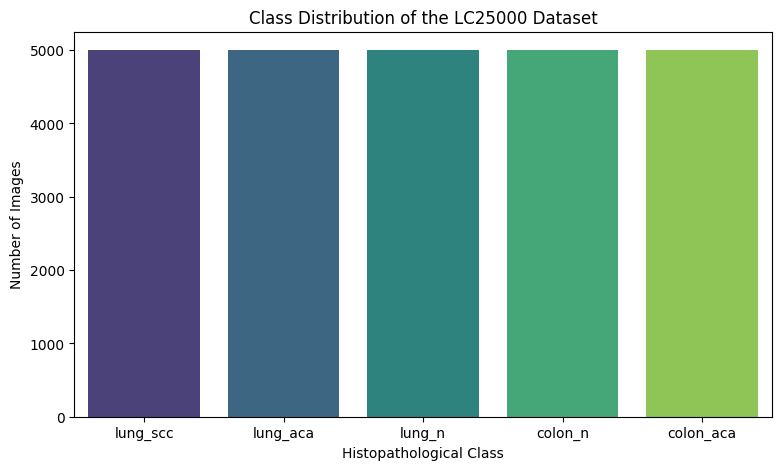

In [7]:
#plotting the class distribution graph

classes=[
    'lung_scc',
    'lung_aca',
    'lung_n',
    'colon_n',
    'colon_aca'
]

class_folders=[lung_path/'lung_scc',
       lung_path/'lung_aca',
       lung_path/'lung_n',
       colon_path/'colon_n',
       colon_path/'colon_aca'
       ]

plt.figure(figsize=(9,5))

sns.barplot(
    x=classes,
    y=[
    len([
        f for f in class_folder.iterdir()
        if f.suffix.lower() in image_extensions
    ])
    for class_folder in class_folders
],

    hue=classes,
    palette='viridis'
)

plt.title("Class Distribution of the LC25000 Dataset")
plt.xlabel("Histopathological Class")
plt.ylabel("Number of Images")

plt.show()



### Distribution plot:

---


- The dataset contains 5 classes across two organ types i.e Lungs and colon
- Lung contains three classes i.e 'lung_scc', 'lung_aca', 'lung_n' and colon contains two classes i.e'colon_n', colon_aca
- Class distribution is perfectly balanced, with each class containing perfectly 5000 images and total 25000 images across all classes


In [10]:
#Seeing clearly if there are any duplicates stored while uploading dataset to drive

total_images=0
i=0
for class_folder in class_folders:
    total_images+=len(os.listdir(class_folder))
    print('-',classes[i],':', len(os.listdir(class_folder)))
    i+=1
print("Total number of images=", total_images)

- lung_scc : 5000
- lung_aca : 5000
- lung_n : 5000
- colon_n : 5000
- colon_aca : 5000
Total number of images= 25000


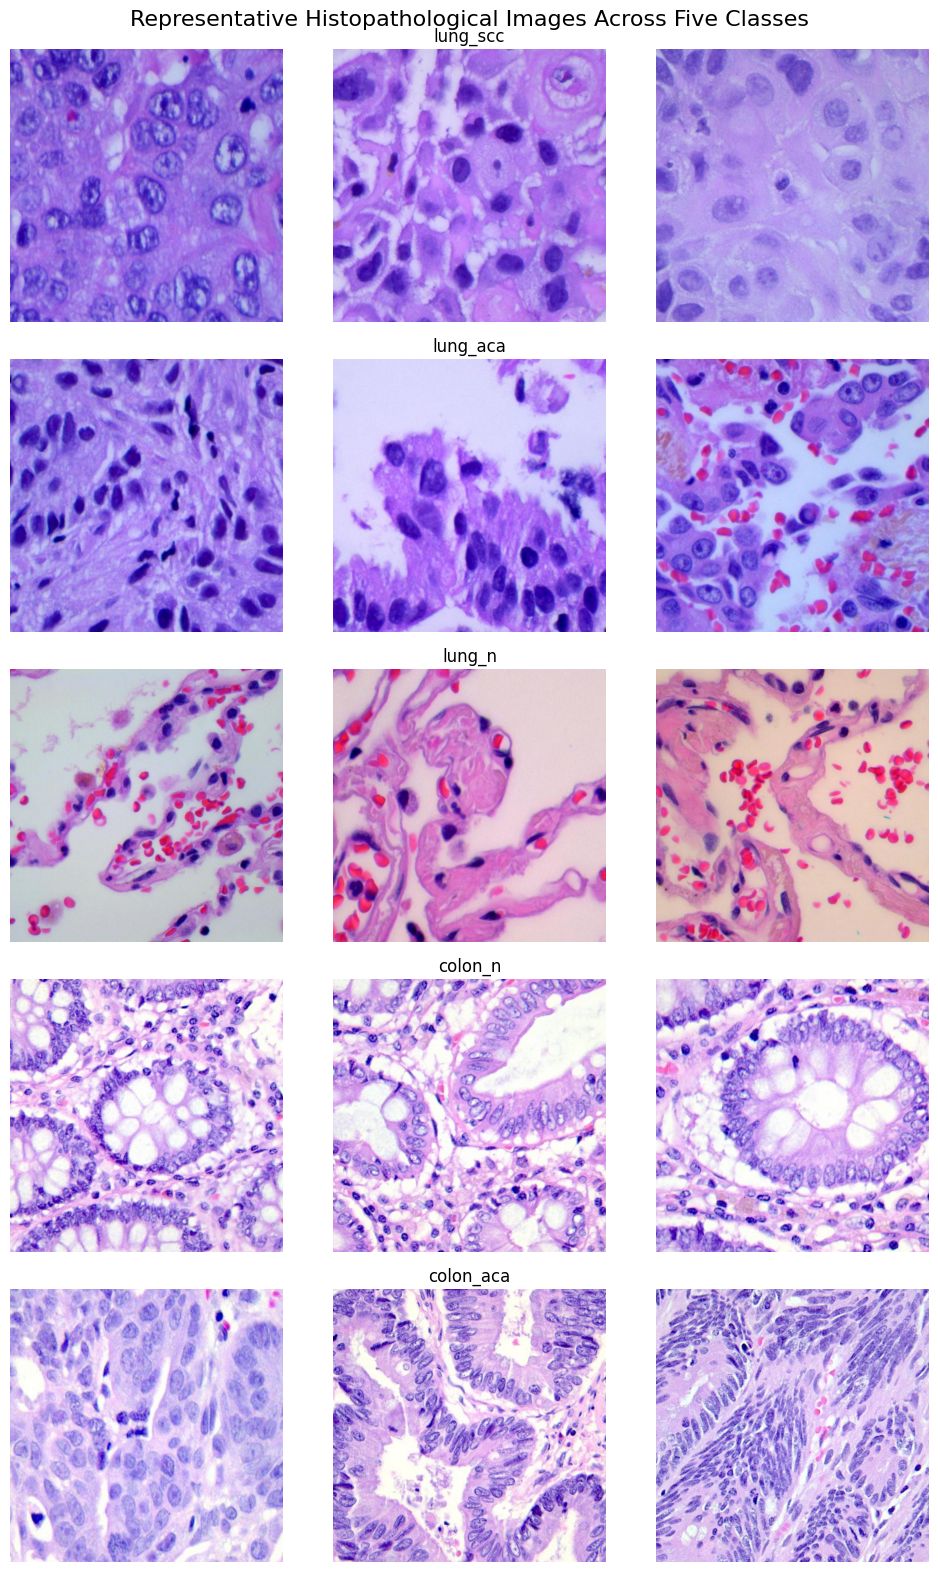

In [11]:
#plotting some random images per class from the dataset

import random
from PIL import Image

class_folders=[lung_path/'lung_scc',
       lung_path/'lung_aca',
       lung_path/'lung_n',
       colon_path/'colon_n',
       colon_path/'colon_aca'
       ]
fig, axes = plt.subplots(5, 3, figsize=(10, 16))
for row, class_folder in enumerate(class_folders):
  img_files=[f for f in class_folder.iterdir()
            if f.suffix.lower() in image_extensions
            ]
  selected_images=random.sample(img_files, 3)
  for col, img_path in enumerate(selected_images):
    img=Image.open(img_path)
    axes[row,col].imshow(img)
    axes[row,col].axis('off')
    if col==1:
      axes[row,col].set_title(class_folder.name, fontsize=12)
plt.suptitle(
    "Representative Histopathological Images Across Five Classes",
    fontsize=16
)
plt.tight_layout()
plt.show()



### Sample images:

---


- The cancerous cells are more dense such as lung_scc, lung_aca, colon_aca, while the noncancerous cells have more spaces among them.
- colon_n have ring like structures, while the same ring like structure appears to be distorted in colon_aca
- lung_n has red cells, it seems like they are blood vessels and has more space compared to lung_scc and lung aca

In [12]:
#Investigating the size of 100 random images per class

Sample_size=100
records=[]

for class_folder in class_folders:
  img_files=[f for f in class_folder.iterdir()
             if f.suffix.lower() in image_extensions
             ]
  sampled_images=random.sample(img_files,Sample_size)
  for img_path in sampled_images:
    img=Image.open(img_path)
    height, width=img.size
    records.append({
        'class': class_folder.name,
        'height': height,
        'width': width,
        'mode':img.mode
    })
dims_df=pd.DataFrame(records)
dims_df.head()

,class,height,width,mode
0,lung_scc,768,768,RGB
1,lung_scc,768,768,RGB
2,lung_scc,768,768,RGB
3,lung_scc,768,768,RGB
4,lung_scc,768,768,RGB


### Image size:
- The images are of the size 768x768 and with three channels each

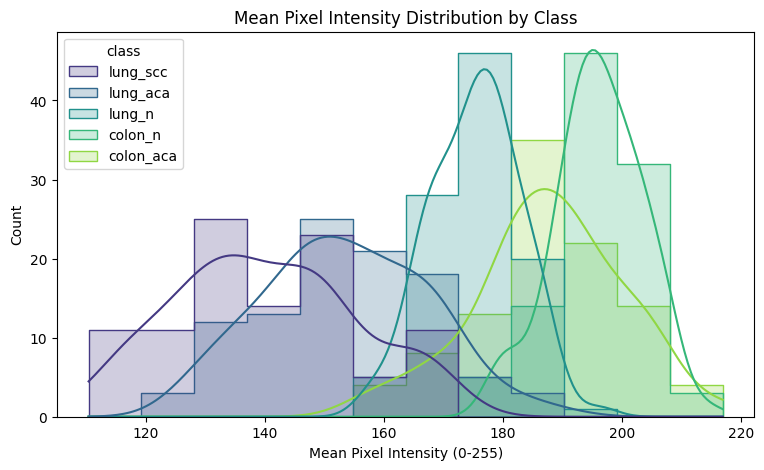

In [13]:
intensity_records=[]

for class_folder in class_folders:
  img_files=[f for f in class_folder.iterdir()
             if f.suffix.lower() in image_extensions
             ]
  sampled_images=random.sample(img_files,Sample_size)
  for img_path in sampled_images:
    img=Image.open(img_path)
    gray=np.array(img.convert('L')) #convert to grayscale
    mean_intensity=np.mean(gray)
    intensity_records.append({
        'class':class_folder.name,
        'mean_intensity':mean_intensity
    })
intensity_df=pd.DataFrame(intensity_records)
plt.figure(figsize=(9,5))
sns.histplot(data=intensity_df, x="mean_intensity", hue='class',
             kde=True, palette='viridis', element='step')
plt.title('Mean Pixel Intensity Distribution by Class')
plt.xlabel('Mean Pixel Intensity (0-255)')
plt.ylabel('Count')
plt.show()

### Intensity Graph observation:

---



- We can clearly see that the cancerous cells of lungs i.e lung_scc and lung_aca are at the darker side, something 110-150, whereas the non-cancerous cells i.e lung_n is at the lighter side
- But there's not much intensity difference between colon_aca and colon_n they are clearly overlapping each other

## Data Preprocessing


---


- Two preprocessing steps are used before training i.e resizing every image to 224x224 and normalization to the 0 to 1 range, and data augmentation using random flips and rotation.

- Resizing gives both models a constant input shape, and normalization keeps pixel values in a small, stable range for faster training.

- Flips and rotations were chosen since a rotated or mirrored tissue sample is still the same tissue. It also reduces overfitting, because the model can no longer memorize a fixed pixel arrangement.

In [14]:
#creating separate list of lung_classes and colong paths

lung_classes=['lung_scc','lung_aca', 'lung_n']
lung_paths=[lung_path/'lung_scc',lung_path/'lung_aca',lung_path/'lung_n']

colon_classes=['colon_n','colon_aca']
colon_paths=[colon_path/'colon_n', colon_path/'colon_aca']



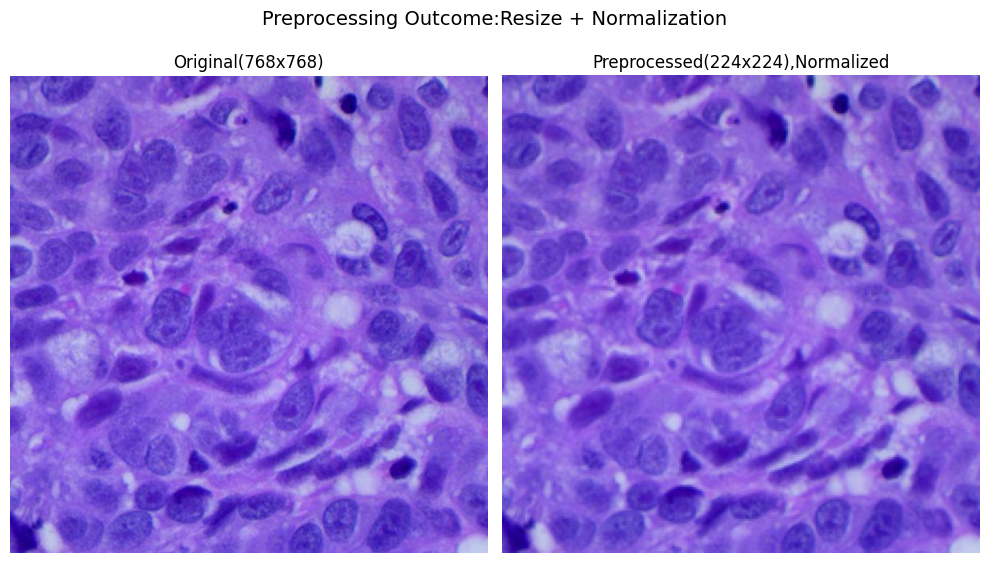

Original pixel range 0 - 255
Preprocessed pixel range 0.0 - 0.9882352941176471


In [15]:
#pick one representative image
#Visualizing the preprocessing on on image i.e Normalization and Resizing on one image
#as required for the report this is illustrative only

sample_path=random.choice([
    f for f in DATASET_PATH.rglob('*')
    if f.is_file() and f.suffix.lower() in image_extensions
])

original_image=Image.open(sample_path)

#target size
TARGET_SIZE=(224,224)

resized_image=original_image.resize(TARGET_SIZE)
resized_array=np.array(resized_image) / 255.0 #normalize [0-1]

#plotting before vs after image
fig,axes=plt.subplots(1,2,figsize=(10,6))

axes[0].imshow(original_image)
axes[0].set_title(f'Original({original_image.size[0]}x{original_image.size[1]})')
axes[0].axis('off')

axes[1].imshow(resized_array)
axes[1].set_title(f'Preprocessed({TARGET_SIZE[0]}x{TARGET_SIZE[1]}),Normalized')
axes[1].axis('off')

plt.suptitle('Preprocessing Outcome:Resize + Normalization', fontsize=14)
plt.tight_layout()
plt.show()

print('Original pixel range',np.array(original_image).min(),"-", np.array(original_image).max())
print('Preprocessed pixel range',resized_array.min(),"-", resized_array.max())

In [31]:
classes=[
    'lung_scc',
    'lung_aca',
    'lung_n',
    'colon_n',
    'colon_aca'
]
class_folders=[lung_path/'lung_scc',
       lung_path/'lung_aca',
       lung_path/'lung_n',
       colon_path/'colon_n',
       colon_path/'colon_aca'
       ]

In [32]:
#Creating a flat folder of symlinks pointing to the 5 class folders
# avoiding duplicating 25000 images on disk

#creating the folder
FLAT_DATASET_PATH=Path('/content/flat_dataset')
FLAT_DATASET_PATH.mkdir(exist_ok=True)

for class_folder, class_names in zip(class_folders, classes):
  link_path=FLAT_DATASET_PATH/class_names
  if not link_path.exists():
    #adding symlink for the folders
    os.symlink(class_folder.resolve(), link_path)

print(os.listdir(FLAT_DATASET_PATH))

['lung_n', 'colon_aca', 'lung_aca', 'lung_scc', 'colon_n']


# Train-Test-Split

In [33]:

# Gather all file paths and labels from the flat symlinked structure
all_paths=[]
all_labels=[]


for idx, class_folder in enumerate(class_folders):
  for f in class_folder.iterdir():
    if f.suffix.lower() in image_extensions:
      #appending the path as string cause further down tensorflow expects the path as string
      #while reading the raw file and in more operations
      all_paths.append(str(f))
      all_labels.append(idx)

all_paths=np.array(all_paths)
all_labels=np.array(all_labels)

train_paths, temp_paths, train_labels, temp_labels=train_test_split(
    all_paths, all_labels,
    test_size=0.30,
    stratify=all_labels,
    random_state=42
)

val_paths, test_paths, val_labels, test_labels=train_test_split(
    temp_paths, temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
)
print(f"Train: {len(train_paths)}, Val: {len(val_paths)}, Test: {len(test_paths)}")

Train: 17500, Val: 3750, Test: 3750


## Resizing and Normalization

In [34]:
from collections import Counter
extensions = Counter(Path(p).suffix.lower() for p in all_paths)
print(extensions)

#image extensions was initially defined because the extensions were not known now as
#As per the output here we can see all the images are .jpeg in dataset

Counter({'.jpeg': 25000})


In [35]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def load_and_preprocess(path, label):
  img=tf.io.read_file(path)
  img=tf.image.decode_jpeg(img, channels=3)
  img=tf.image.resize(img, IMG_SIZE) #resizing
  img=img/255.0 #normalization
  return img, label

def make_dataset(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(paths),
            seed=42,
            reshuffle_each_iteration=True
        )

    ds = ds.map(
        load_and_preprocess,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    ds = ds.batch(BATCH_SIZE) #one tensor shape might become (BATCH_SIZE, 224,224,3)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds



In [36]:
#Applying preprocessing to train, test, val data splits

train_ds = make_dataset(train_paths, train_labels, shuffle=True) #shuffling needs to be applied while training time only
val_ds = make_dataset(val_paths, val_labels)
test_ds = make_dataset(test_paths, test_labels)

# MODEL BUILDING

In [39]:
from tensorflow.keras import layers, models, callbacks
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
], name="data_augmentation")

### Custom CNN Architecture

---



- The custom CNN uses four convolutional blocks (32, 64, 128, and 256 filters), each followed by BatchNormalization and MaxPooling.

- GlobalAveragePooling2D is used instead of Flatten before the final dense layers. Flatten would create millions of parameters for this architecture in the following dense layer and a high risk of overfitting given the dataset size.

- A Dropout layer (0.4) is used before the output layer to reduce overfitting

In [41]:

# Custom CNN architecture
model_cnn = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(len(classes), activation='softmax')  # classes
])



In [ ]:
# Model compiling using adam as the optimizer
model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

# Callbacks
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,877 (1.62 MB)

 Trainable params: 422,917 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
checkpoint = callbacks.ModelCheckpoint(
    'best_custom_cnn.keras',
    monitor='val_loss',
    save_best_only=True
)

#Train
history_cnn = model_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 90s 147ms/step - accuracy: 0.8775 - loss: 0.3071 - val_accuracy: 0.7491 - val_loss: 0.7007
Epoch 2/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 135s 143ms/step - accuracy: 0.9341 - loss: 0.1731 - val_accuracy: 0.3664 - val_loss: 8.2086
Epoch 3/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 90s 164ms/step - accuracy: 0.9503 - loss: 0.1258 - val_accuracy: 0.6936 - val_loss: 3.8332
Epoch 4/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 80s 146ms/step - accuracy: 0.9595 - loss: 0.1083 - val_accuracy: 0.4976 - val_loss: 4.8164
Epoch 5/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 80s 145ms/step - accuracy: 0.9662 - loss: 0.0902 - val_accuracy: 0.8936 - val_loss: 0.3852
Epoch 6/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 80s 145ms/step - accuracy: 0.9717 - loss: 0.0735 - val_accuracy: 0.6760 - val_loss: 1.5646
Epoch 7/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 79s 144ms/step - accuracy: 0.9770 - loss: 0.0610 - val_accuracy: 0.7592 - val_loss: 2.3783
Epoch 8/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 90s 163ms/step - accuracy: 0.9786 - loss: 

### Pretrained Model: EfficientNetB0

---



- EfficientNetB0 was selected as the pretrained model after googling common choices for image classification tasks, since it offers a strong balance between accuracy and computational efficiency,I choosed it.

- The base model is has the ImageNet weights and its layers are frozen.

- preprocess_input is applied inside the model itself, directly after the input layer, so that the correct pixel scaling for EfficientNetB0 is always applied automatically.

In [ ]:
def load_raw(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label  # no normalization as EfficientNet's preprocess_input handles it

def make_dataset_pretrained(paths, labels, shuffle=False, cache_name=None):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)
    ds = ds.map(load_raw, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    if cache_name:
        ds = ds.cache(f'/content/{cache_name}_pretrained_cache')
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_pt = make_dataset_pretrained(train_paths, train_labels, shuffle=True, cache_name='train')
val_ds_pt = make_dataset_pretrained(val_paths, val_labels, cache_name='val')
test_ds_pt = make_dataset_pretrained(test_paths, test_labels, cache_name='test')

In [42]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input


base_model = EfficientNetB0(
    #chopping of the 1000 prediction class at end so we can use just the feature detector
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # freezing pretrained weights initially

inputs = layers.Input(shape=(224, 224, 3))
x = preprocess_input(inputs)          # specific scaling with respect to model
x = base_model(x, training=False) #training=false stops the batchnorm layers from getting updated
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(len(classes), activation='softmax')(x)

model_pretrained = models.Model(inputs, outputs)

model_pretrained.compile(

    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_pretrained.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,184 (16.08 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
checkpoint_pt = callbacks.ModelCheckpoint(
    'best_pretrained_model.keras',
    monitor='val_loss',
    save_best_only=True
)
early_stop_pt = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_pretrained = model_pretrained.fit(
    train_ds_pt,
    validation_data=val_ds_pt,
    epochs=15,
    callbacks=[early_stop_pt, checkpoint_pt]
)

Epoch 1/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 123s 185ms/step - accuracy: 0.9486 - loss: 0.1422 - val_accuracy: 0.9765 - val_loss: 0.0617
Epoch 2/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 55s 101ms/step - accuracy: 0.9750 - loss: 0.0661 - val_accuracy: 0.9880 - val_loss: 0.0339
Epoch 3/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 55s 101ms/step - accuracy: 0.9841 - loss: 0.0446 - val_accuracy: 0.9912 - val_loss: 0.0237
Epoch 4/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 56s 103ms/step - accuracy: 0.9849 - loss: 0.0372 - val_accuracy: 0.9931 - val_loss: 0.0192
Epoch 5/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 56s 103ms/step - accuracy: 0.9888 - loss: 0.0324 - val_accuracy: 0.9957 - val_loss: 0.0126
Epoch 6/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 55s 101ms/step - accuracy: 0.9902 - loss: 0.0281 - val_accuracy: 0.9971 - val_loss: 0.0100
Epoch 7/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 54s 99ms/step - accuracy: 0.9902 - loss: 0.0275 - val_accuracy: 0.9968 - val_loss: 0.0101
Epoch 8/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 82s 100ms/step - accuracy: 0.9909 - loss: 0

# MODEL EVALUATION

In [ ]:
history_cnn_test=model_cnn.evaluate(test_ds)

118/118 ━━━━━━━━━━━━━━━━━━━━ 16s 131ms/step - accuracy: 0.9947 - loss: 0.0163


In [ ]:
history_pretrained_test=model_pretrained.evaluate(test_ds_pt)


118/118 ━━━━━━━━━━━━━━━━━━━━ 34s 287ms/step - accuracy: 0.9973 - loss: 0.0061


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_true = test_labels

# Custom CNN
y_pred_probs_cnn = model_cnn.predict(test_ds)
y_pred_cnn = np.argmax(y_pred_probs_cnn, axis=1)

print("=== Custom CNN ===")
print(classification_report(y_true, y_pred_cnn, target_names=classes))
print(f"Cohen's Kappa: {cohen_kappa_score(y_true, y_pred_cnn):.4f}")
print(f"Macro ROC-AUC: {roc_auc_score(y_true, y_pred_probs_cnn, multi_class='ovr', average='macro'):.4f}")

# Pretrained model
y_pred_probs_pt = model_pretrained.predict(test_ds_pt)
y_pred_pt = np.argmax(y_pred_probs_pt, axis=1)

print("\n=== Pretrained (EfficientNetB0) ===")
print(classification_report(y_true, y_pred_pt, target_names=classes))
print(f"Cohen's Kappa: {cohen_kappa_score(y_true, y_pred_pt):.4f}")
print(f"Macro ROC-AUC: {roc_auc_score(y_true, y_pred_probs_pt, multi_class='ovr', average='macro'):.4f}")

118/118 ━━━━━━━━━━━━━━━━━━━━ 57s 78ms/step
=== Custom CNN ===
              precision    recall  f1-score   support

    lung_scc       1.00      0.99      0.99       750
    lung_aca       0.99      1.00      0.99       750
      lung_n       1.00      1.00      1.00       750
     colon_n       1.00      0.99      0.99       750
   colon_aca       0.99      1.00      0.99       750

    accuracy                           0.99      3750
   macro avg       0.99      0.99      0.99      3750
weighted avg       0.99      0.99      0.99      3750

Cohen's Kappa: 0.9933
Macro ROC-AUC: 1.0000
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step

=== Pretrained (EfficientNetB0) ===
              precision    recall  f1-score   support

    lung_scc       1.00      0.99      1.00       750
    lung_aca       0.99      1.00      1.00       750
      lung_n       1.00      1.00      1.00       750
     colon_n       1.00      1.00      1.00       750
   colon_aca       1.00      1.00      1.00       750



## Observation:

---
- Both the models achieved almost perfect precision, recall, and F1-scores among all five classes, but pretrained EfficientNetB0 scoring higher comparatively, kappa value is higher: 0.9967 vs 0.9933
- A macro ROC_AUC of 1.0000 shows that both models confidence scores fully separate individual classes from the rest, with no overlap between correct and incorrect classes.
-The consistent values of accuracy, macro_avg,and weighted avg shows uniform or good performance across classes


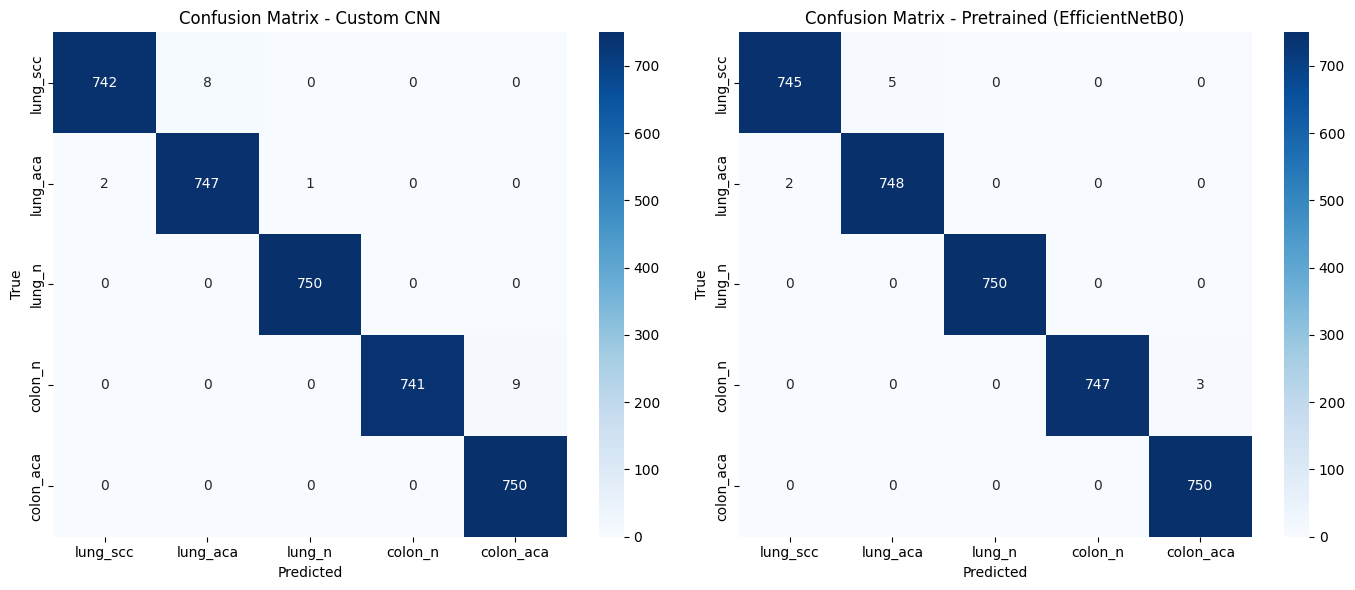

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

cm_cnn = confusion_matrix(y_true, y_pred_cnn)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title('Confusion Matrix - Custom CNN')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

cm_pt = confusion_matrix(y_true, y_pred_pt)
sns.heatmap(cm_pt, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title('Confusion Matrix - Pretrained (EfficientNetB0)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

## Observation:

---


- Both models make very less false predictions, and no error crosses organs which means lung is never confused with colon
- lung_n is classified perfectly 750/750 in both models.

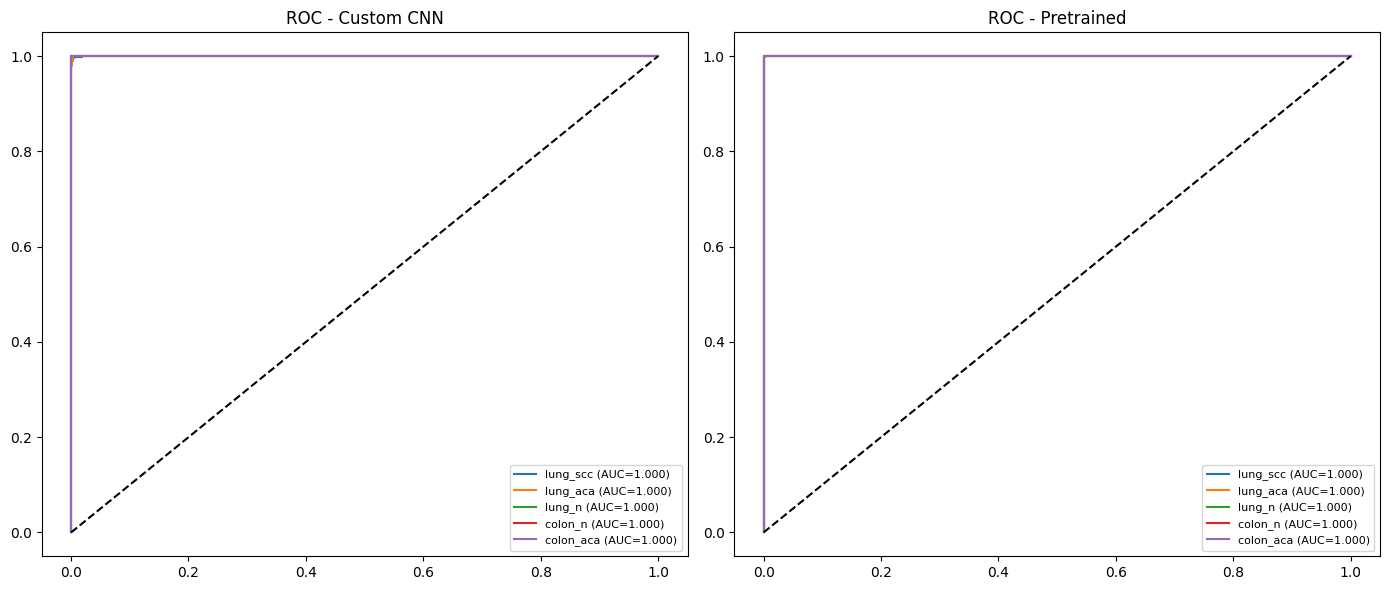

In [ ]:
y_true_bin = label_binarize(y_true, classes=range(len(classes)))

fig, axes = plt.subplots(1, 2, figsize=(14,6))

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs_cnn[:, i])
    axes[0].plot(fpr, tpr, label=f'{class_name} (AUC={auc(fpr,tpr):.3f})')
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_title('ROC - Custom CNN'); axes[0].legend(fontsize=8)

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs_pt[:, i])
    axes[1].plot(fpr, tpr, label=f'{class_name} (AUC={auc(fpr,tpr):.3f})')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('ROC - Pretrained'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Observation:

---


- Both models achieve a perfect AUC of 1.000 for every class, with individual classes confidence scores totally separate each class from the rest, with no overlap
- This metrics confirms strong class separation

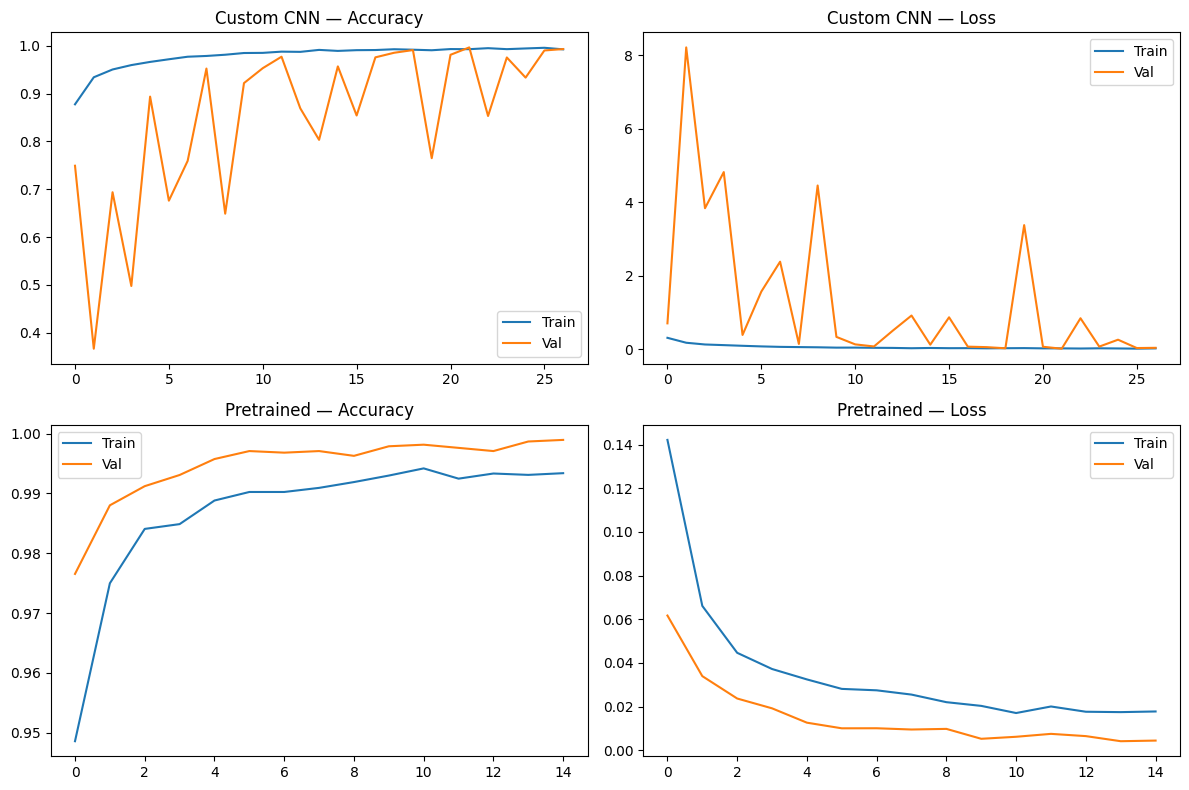

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

axes[0,0].plot(history_cnn.history['accuracy'], label='Train')
axes[0,0].plot(history_cnn.history['val_accuracy'], label='Val')
axes[0,0].set_title('Custom CNN — Accuracy'); axes[0,0].legend()

axes[0,1].plot(history_cnn.history['loss'], label='Train')
axes[0,1].plot(history_cnn.history['val_loss'], label='Val')
axes[0,1].set_title('Custom CNN — Loss'); axes[0,1].legend()

axes[1,0].plot(history_pretrained.history['accuracy'], label='Train')
axes[1,0].plot(history_pretrained.history['val_accuracy'], label='Val')
axes[1,0].set_title('Pretrained — Accuracy'); axes[1,0].legend()

axes[1,1].plot(history_pretrained.history['loss'], label='Train')
axes[1,1].plot(history_pretrained.history['val_loss'], label='Val')
axes[1,1].set_title('Pretrained — Loss'); axes[1,1].legend()

plt.tight_layout()
plt.show()

## Observation:

---

- The custom CNN"s validation accuracy/loss oscillate too much during training, Its likely due to BatchNormalization statistics lagging behind a high learning rate
- The pretrained EfficientNetB0 trains smoothly.
-Despite the unstable training, the custom CNN's best saved checkpoint performed well on the test set, it means it generalized well

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    'Metric': ['Test Accuracy', 'Test Loss', "Cohen's Kappa", 'Macro ROC-AUC', 'Total Params'],
    'Custom CNN': [0.9947, 0.0163, 0.9933, 1.0000, model_cnn.count_params()],
    'Pretrained (EfficientNetB0)': [0.9973, 0.0061, 0.9967, 1.0000, model_pretrained.count_params()]
})
comparison_df

,Metric,Custom CNN,Pretrained (EfficientNetB0)
0,Test Accuracy,0.9947,9.973000e-01
1,Test Loss,0.0163,6.100000e-03
2,Cohen's Kappa,0.9933,9.967000e-01
3,Macro ROC-AUC,1.0000,1.000000e+00
4,Total Params,423877.0000,4.214184e+06


## Observation:

---

- The pretrained model slightly outperforms the custom CNN on ever metric, higher accuracy, lower loss and higher cappa.
- The small accuracy cameat cost, pretrained model has 10 times more parameters as we can observe in the DataFrame.
- The custom CNN remains a strong, lightweight option where model size matters more than a fraction of percent in accuracy.

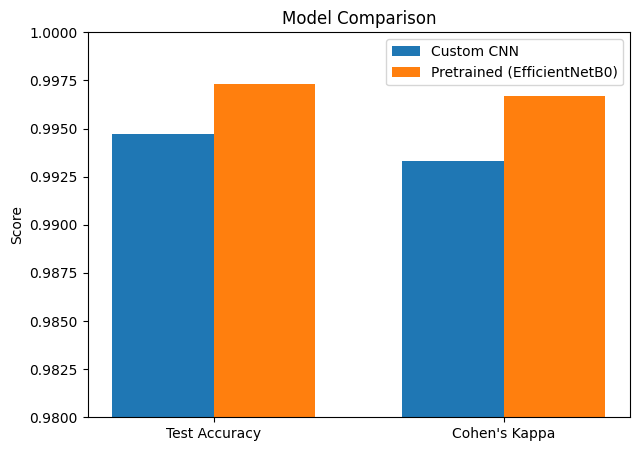

In [ ]:
# Grouped bar chart
metrics = ['Test Accuracy', "Cohen's Kappa"]
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(7,5))
ax.bar(x - width/2, [0.9947, 0.9933], width, label='Custom CNN')
ax.bar(x + width/2, [0.9973, 0.9967], width, label='Pretrained (EfficientNetB0)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.98, 1.0)
ax.set_ylabel('Score')
ax.set_title('Model Comparison')
ax.legend()
plt.show()

### Advantages and Model choice

- The custom CNN's advantage is its small size (423,877 parameters), making it faster and cheaper to deploy. Its limitation is a less stable training process, requiring early stopping to recover reliable weights.

- EfficientNetB0's advantage is slightly higher accuracy and Kappa, with smoother training since its frozen base doesn't shift. Its limitation is its much larger size (4,214,184 parameters) for only a marginal accuracy gain.

- Overall, EfficientNetB0 is the better choice when accuracy and training reliability matter most, as is typical for a diagnostic task. The custom CNN remains a good option where model size and inference speed matter more, such as lightweight deployment.



---



## Conclusions:

---
## Summary of Findings:

- Both a custom CNN and a pretrained EfficientNetB0 were trained to classify LC25000 histopathology images into 5 classes.
- The custom CNN reached 99.47% accuracy (Kappa 0.9933), and EfficientNetB0 reached 99.73% (Kappa 0.9967)
- EfficientNetB0 slightly outperformed the CNN despite having 10 times more parameters.
- The few errors that occured were among the similar class pairs e.g lung_scc vs lung_aca, and it never mis interpreted lungs for colon

## Limitations and Possible Sources of Bias

- The custom CNN's training was unstable (val_loss spiked as high as 8.2) likely due to BatchNormalization interacting poorly with the learning rate used. The final model relied on early stopping to recover a good checkpoint rather than a fully stable run

## Recommendations for Future Work

- Apply a lower/adaptive learning rate and re-run the custom CNN to confirm a stable training curve.
- Test both models on histopathology images from an external source to check true generalisation.

#Streamlit web app

In [ ]:
model_pretrained.save('/content/best_pretrained_model.keras')

In [ ]:
from google.colab import files
files.download('/content/best_pretrained_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil, os
from pathlib import Path

sample_dir = Path('/content/streamlit_examples')
sample_dir.mkdir(exist_ok=True)

# Grab one test image per class
sample_paths = {}
for idx, class_name in enumerate(classes):
    for path, label in zip(test_paths, test_labels):
        if label == idx:
            sample_paths[class_name] = path
            break

for class_name, path in sample_paths.items():
    shutil.copy(path, sample_dir / f"{class_name}.jpeg")

print(os.listdir(sample_dir))

['lung_scc.jpeg', 'colon_aca.jpeg', 'lung_aca.jpeg', 'lung_n.jpeg', 'colon_n.jpeg']


In [ ]:
shutil.make_archive('/content/streamlit_examples', 'zip', sample_dir)
files.download('/content/streamlit_examples.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>